# 02 — KL Divergence & Mutual Information ⭐

**The single highest-interview-yield notebook in this subchapter for anyone touching modern generative models.** KL divergence underlies VAEs, diffusion models, RLHF/PPO, and knowledge distillation; mutual information underlies feature selection and representation-learning evaluation.

Standard treatment (Cover & Thomas, *Elements of Information Theory*; MacKay, *Information Theory, Inference, and Learning Algorithms*) — see the note on references in notebook 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## KL divergence: the gap left by cross-entropy

From the last notebook: `H(p,q) ≥ H(p)`, always. The gap between them is the **Kullback-Leibler (KL) divergence**:

```
KL(p‖q) = H(p, q) - H(p) = Σ p(x) log₂ [p(x) / q(x)]
```

It measures how much *extra* cost (in bits) you pay for using the wrong distribution `q` instead of the true `p`. Two properties worth having cold:
- **`KL(p‖q) ≥ 0` always, with equality iff `p = q`** (Gibbs' inequality) — this is exactly why gradient descent on cross-entropy loss can't do better than matching the true distribution.
- **`KL(p‖q) ≠ KL(q‖p)` in general — it's not a true distance/metric.**

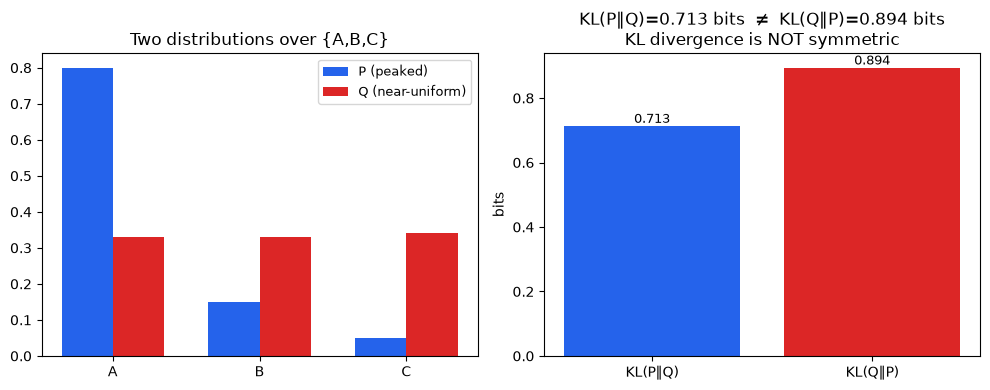

KL(P||Q) = 0.7131 bits, KL(Q||P) = 0.8941 bits


In [2]:
def kl_divergence(p, q):
    p, q = np.array(p), np.array(q)
    return np.sum(p * np.log2(p / q))

def visualize_kl_asymmetry(savepath: Path = None):
    categories = ["A", "B", "C"]
    P = np.array([0.80, 0.15, 0.05])
    Q = np.array([0.33, 0.33, 0.34])

    kl_pq = kl_divergence(P, Q)
    kl_qp = kl_divergence(Q, P)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(3)
    width = 0.35

    ax = axes[0]
    ax.bar(x - width/2, P, width, color="#2563eb", label="P (peaked)")
    ax.bar(x + width/2, Q, width, color="#dc2626", label="Q (near-uniform)")
    ax.set_xticks(x); ax.set_xticklabels(categories)
    ax.legend(fontsize=9)
    ax.set_title("Two distributions over {A,B,C}")

    ax2 = axes[1]
    ax2.bar(["KL(P‖Q)", "KL(Q‖P)"], [kl_pq, kl_qp], color=["#2563eb", "#dc2626"])
    ax2.set_ylabel("bits")
    ax2.set_title(f"KL(P‖Q)={kl_pq:.3f} bits  ≠  KL(Q‖P)={kl_qp:.3f} bits\nKL divergence is NOT symmetric")
    for i, v in enumerate([kl_pq, kl_qp]):
        ax2.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return kl_pq, kl_qp

kl_pq, kl_qp = visualize_kl_asymmetry(FIG_DIR / "kl_asymmetry.png")
print(f"KL(P||Q) = {kl_pq:.4f} bits, KL(Q||P) = {kl_qp:.4f} bits")

## Forward vs. reverse KL: mode-covering vs. mode-seeking

The asymmetry isn't just a technicality — which direction you minimize changes *what kind of mistake* your approximation makes. Fit a single Gaussian `q` to a bimodal target `p`, once by minimizing `KL(p‖q)` (forward) and once by minimizing `KL(q‖p)` (reverse).

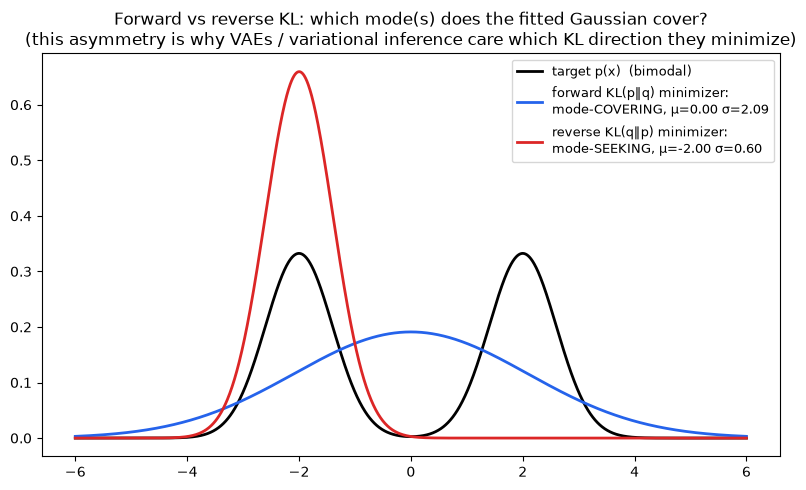

In [3]:
def gaussian_pdf(x, mu, sigma):
    return (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

def target_p(x):
    return 0.5*gaussian_pdf(x, -2, 0.6) + 0.5*gaussian_pdf(x, 2, 0.6)

def visualize_forward_reverse_kl(savepath: Path = None):
    x = np.linspace(-6, 6, 2000)
    dx = x[1] - x[0]
    p = target_p(x)
    p = p / (p.sum() * dx)

    # Forward KL(p||q): for a Gaussian family, the minimizer is exactly moment matching
    mean_p = np.sum(x * p) * dx
    var_p = np.sum((x - mean_p)**2 * p) * dx
    mu_fwd, sigma_fwd = mean_p, np.sqrt(var_p)

    # Reverse KL(q||p): no closed form -- numeric optimization, mode-seeking
    def reverse_kl(params):
        mu, log_sigma = params
        sigma = np.exp(log_sigma)
        q = gaussian_pdf(x, mu, sigma)
        q = np.clip(q, 1e-12, None)
        p_safe = np.clip(p, 1e-12, None)
        return np.sum(q * (np.log(q) - np.log(p_safe))) * dx

    best = None
    for start_mu in [-2, 2]:
        res = minimize(reverse_kl, x0=[start_mu, np.log(0.6)], method="Nelder-Mead")
        if best is None or res.fun < best.fun:
            best = res
    mu_rev, sigma_rev = best.x[0], np.exp(best.x[1])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, p, color="black", linewidth=2, label="target p(x)  (bimodal)")
    ax.plot(x, gaussian_pdf(x, mu_fwd, sigma_fwd), color="#2563eb", linewidth=2,
            label=f"forward KL(p‖q) minimizer:\nmode-COVERING, μ={mu_fwd:.2f} σ={sigma_fwd:.2f}")
    ax.plot(x, gaussian_pdf(x, mu_rev, sigma_rev), color="#dc2626", linewidth=2,
            label=f"reverse KL(q‖p) minimizer:\nmode-SEEKING, μ={mu_rev:.2f} σ={sigma_rev:.2f}")
    ax.legend(fontsize=9)
    ax.set_title("Forward vs reverse KL: which mode(s) does the fitted Gaussian cover?\n(this asymmetry is why VAEs / variational inference care which KL direction they minimize)")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_forward_reverse_kl(FIG_DIR / "forward_reverse_kl.png")

**Forward KL `KL(p‖q)`** (blue) is *mode-covering*: because `p(x) log[p(x)/q(x)]` blows up wherever `p` has mass but `q` doesn't, the optimizer is forced to spread `q` wide enough to cover everywhere `p` has probability — even if that means putting mass in the valley between the two modes, where the true density is actually low.

**Reverse KL `KL(q‖p)`** (red) is *mode-seeking*: the penalty only accumulates where `q` itself has mass, so it's free to collapse onto a single mode and simply ignore the rest of `p` entirely, as long as wherever it does place mass, `p` is high there too.

**Why this matters concretely:** variational inference (used in VAEs) minimizes `KL(q‖p)` — the reverse direction — which is part of why VAE posteriors tend to be mode-seeking / under-dispersed. Maximum likelihood training (used for most standard classifiers and generative models, including autoregressive language models) is equivalent to minimizing forward KL — mode-covering, which is part of why maximum-likelihood-trained generative models sometimes hedge across multiple plausible outputs rather than committing to one.

## Mutual information: correlation's more powerful cousin

**Mutual information** `I(X;Y)` measures how much knowing `X` reduces your uncertainty about `Y` — equivalently, `I(X;Y) = KL(P(X,Y) ‖ P(X)P(Y))`, the KL divergence between the actual joint distribution and what the joint would look like if `X` and `Y` were independent. `I(X;Y) = 0` exactly when `X` and `Y` are independent (unlike correlation, which can be zero even for strongly dependent variables — remember the `Y=X²` example from the Statistics chapter?).

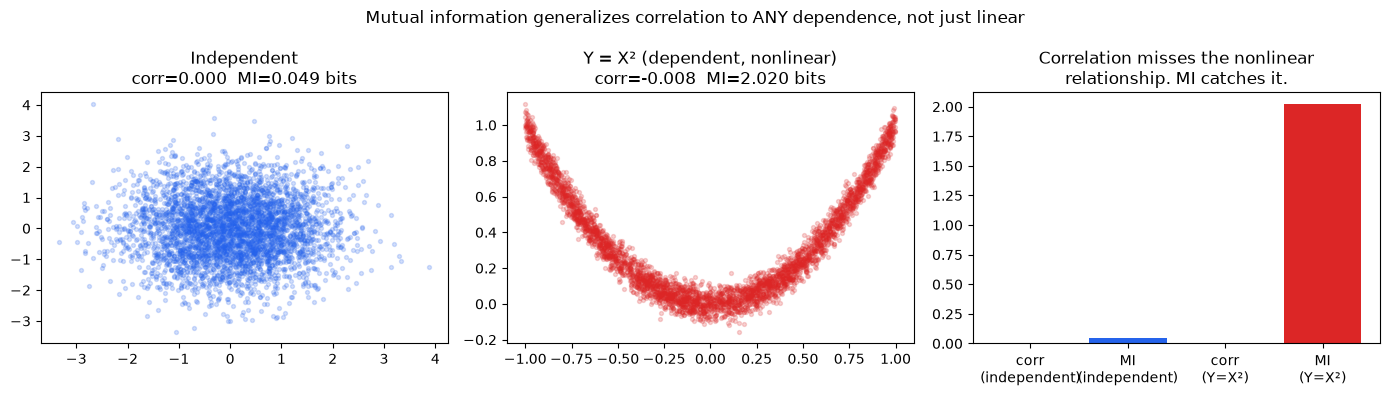

Y=X² case: correlation=-0.0078 (near zero, misses it), MI=2.0198 bits (catches it)


In [4]:
def mutual_information_discrete(x, y, bins=20):
    c_xy = np.histogram2d(x, y, bins)[0]
    p_xy = c_xy / c_xy.sum()
    p_x = p_xy.sum(axis=1, keepdims=True)
    p_y = p_xy.sum(axis=0, keepdims=True)
    p_ind = p_x * p_y
    nz = p_xy > 0
    return np.sum(p_xy[nz] * np.log2(p_xy[nz] / p_ind[nz]))

def visualize_mi_vs_correlation(savepath: Path = None, rng=None):
    rng = rng or np.random.default_rng(3)
    n = 4000

    x_indep = rng.normal(size=n)
    y_indep = rng.normal(size=n)

    x_dep = rng.uniform(-1, 1, size=n)
    y_dep = x_dep**2 + rng.normal(scale=0.05, size=n)

    corr_indep = np.corrcoef(x_indep, y_indep)[0, 1]
    corr_dep = np.corrcoef(x_dep, y_dep)[0, 1]
    mi_indep = mutual_information_discrete(x_indep, y_indep)
    mi_dep = mutual_information_discrete(x_dep, y_dep)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].scatter(x_indep, y_indep, alpha=0.2, s=8, color="#2563eb")
    axes[0].set_title(f"Independent\ncorr={corr_indep:.3f}  MI={mi_indep:.3f} bits")

    axes[1].scatter(x_dep, y_dep, alpha=0.2, s=8, color="#dc2626")
    axes[1].set_title(f"Y = X² (dependent, nonlinear)\ncorr={corr_dep:.3f}  MI={mi_dep:.3f} bits")

    axes[2].bar(["corr\n(independent)", "MI\n(independent)", "corr\n(Y=X²)", "MI\n(Y=X²)"],
                [abs(corr_indep), mi_indep, abs(corr_dep), mi_dep],
                color=["#93c5fd", "#2563eb", "#fca5a5", "#dc2626"])
    axes[2].set_title("Correlation misses the nonlinear\nrelationship. MI catches it.")

    fig.suptitle("Mutual information generalizes correlation to ANY dependence, not just linear")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return corr_dep, mi_dep

corr_dep, mi_dep = visualize_mi_vs_correlation(FIG_DIR / "mi_vs_correlation.png")
print(f"Y=X² case: correlation={corr_dep:.4f} (near zero, misses it), MI={mi_dep:.4f} bits (catches it)")

The middle panel is the exact same `Y = X²` relationship that broke correlation back in the Statistics chapter — correlation is still ≈0 here, but mutual information registers roughly 2 bits of shared information, correctly flagging the (deterministic, if you squint past the added noise) dependence.

**Where this shows up in practice:** mutual-information-based feature selection catches predictive features that a correlation-based filter would silently discard; mutual information between an embedding and its inputs is used to diagnose representation collapse (an encoder that's ignoring parts of its input will show low MI with those parts); and the InfoNCE objective behind contrastive representation learning methods (SimCLR, CLIP) is, at its core, a mutual-information lower bound being maximized.

---

## Self-check before moving on

- [ ] I can define KL divergence in terms of cross-entropy minus entropy
- [ ] I can state why `KL(p‖q) ≥ 0` and why it's not symmetric
- [ ] I can explain mode-covering (forward KL) vs. mode-seeking (reverse KL) behavior, and name one model family that uses each
- [ ] I can define mutual information and explain why it catches nonlinear dependence that correlation misses
- [ ] I can name at least one practical ML use of mutual information beyond feature selection

Next: `03-ml-applications-entropy.ipynb`